In [1]:
# 데이터를 불러오는 작업

import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
print(iris.data.shape)

data = pd.DataFrame(iris.data, columns=iris.feature_names)
data

(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
result = scaler.fit_transform(data)
data_scaled = pd.DataFrame(result, columns=iris.feature_names)
data_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


In [3]:
from sklearn.decomposition import PCA

pca = PCA() # n_components를 생략하면 특성수 만큼 주성분 생성
pca_data = pca.fit_transform(data_scaled)
pca_data = pd.DataFrame(pca_data, columns=iris.feature_names)
pca_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


In [4]:
# 주선분 분석이 다 끝나고 나면 

pca.explained_variance_ # 공분산 행렬의 eigen value(PC)값

array([2.93808505, 0.9201649 , 0.14774182, 0.02085386])

In [5]:
ratio = pca.explained_variance_ratio_
ratio

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

,V_ration
PC1,0.729624
PC2,0.228508
PC3,0.036689
PC4,0.005179


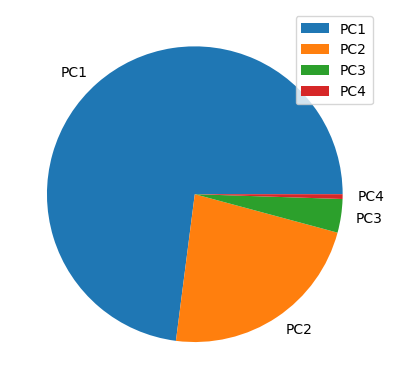

In [6]:
df_v = pd.DataFrame(ratio, index=['PC1', 'PC2', 'PC3', 'PC4'], columns=['V_ration'])
df_v.plot.pie(y='V_ration')
df_v

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # 피쳐가 4개인데 2개로 바꾼거임
pca_data = pca.fit_transform(data_scaled)

pca_data = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_data

,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835
...,...,...
145,1.870503,0.386966
146,1.564580,-0.896687
147,1.521170,0.269069
148,1.372788,1.011254


In [8]:
ratio = pca.explained_variance_ratio_
ratio

array([0.72962445, 0.22850762])

In [9]:
target = pd.DataFrame(iris.target, columns=['species'])
target['species'] = target['species'].apply(lambda x: iris.target_names[x])
pca_df = pd.concat([pca_data, target], axis=1)
pca_df

,PC1,PC2,species
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa
...,...,...,...
145,1.870503,0.386966,virginica
146,1.564580,-0.896687,virginica
147,1.521170,0.269069,virginica
148,1.372788,1.011254,virginica


In [10]:
# 이제 시각화를 해보자

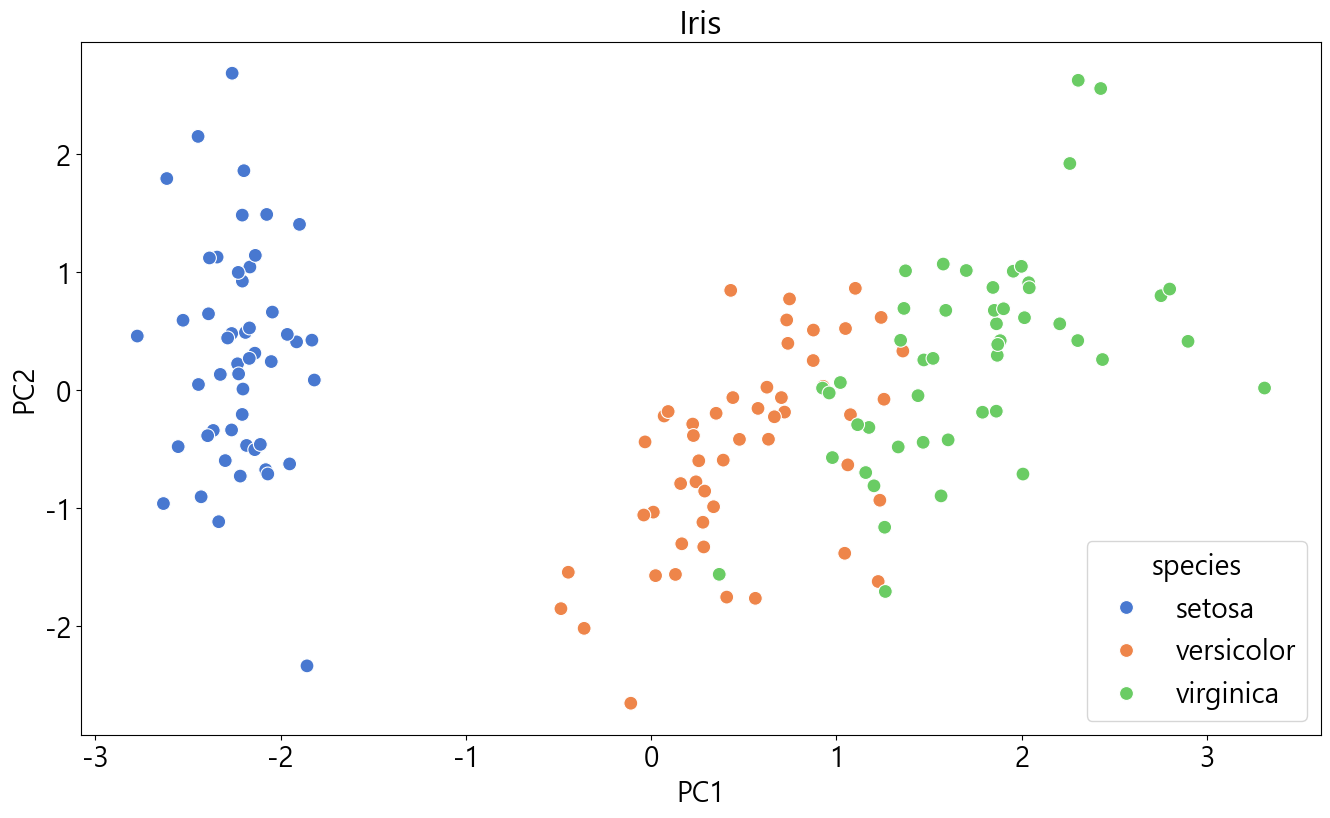

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns

mlp.rcParams['font.size'] = 20
mlp.rcParams['font.family'] = 'Malgun Gothic'
mlp.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(16, 9))
sns.set_palette(sns.color_palette("muted"))

sns.scatterplot(x=pca_df['PC1'], 
                y=pca_df['PC2'],
                hue=pca_df['species'],
                s=100,
                palette=sns.color_palette('muted', n_colors=3))
plt.title('Iris')
plt.show()